### Dependencies

In [62]:
# %pip install pandas numpy seaborn matplotlib scikit-learn wfdb 

### Imports

In [63]:
import wfdb #PhysioNet's Library for reading, writing, and processing physiologic signals
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [64]:
cudb_path = 'data/cu-ventricular-tachyarrhythmia-database-1.0.0'

with open(os.path.join(cudb_path, 'RECORDS')) as f:
    records = [line.strip() for line in f if line.strip()]

print(f"Found {len(records)} records:", records)

Found 35 records: ['cu01', 'cu02', 'cu03', 'cu04', 'cu05', 'cu06', 'cu07', 'cu08', 'cu09', 'cu10', 'cu11', 'cu12', 'cu13', 'cu14', 'cu15', 'cu16', 'cu17', 'cu18', 'cu19', 'cu20', 'cu21', 'cu22', 'cu23', 'cu24', 'cu25', 'cu26', 'cu27', 'cu28', 'cu29', 'cu30', 'cu31', 'cu32', 'cu33', 'cu34', 'cu35']


In [65]:
rates = set()
for rec in records:
    r = wfdb.rdrecord(os.path.join(cudb_path, rec))
    rates.add(r.fs)

print("Distinct sampling rates found across all CUDB records:", rates)

Distinct sampling rates found across all CUDB records: {250}


In [66]:
ann = wfdb.rdann(os.path.join(cudb_path, 'cu01'), 'atr')
print(set(ann.symbol))

{'N', ']', '[', '+'}


In [67]:
results = []
for rec in records:
    rec_path = os.path.join(cudb_path, rec)
    ann = wfdb.rdann(rec_path, 'atr')
    record_len = wfdb.rdrecord(rec_path).p_signal.shape[0]

    markers = [(s, sym) for s, sym in zip(ann.sample, ann.symbol) if sym in ['[', ']', '+']]
    results.append((rec, record_len, markers))

for rec, record_len, markers in results:
    num_episodes = sum(1 for _, sym in markers if sym == '[')
    ends_at_finish = any(sym == ']' and s >= record_len - 5 for s, sym in markers)
    print(f"{rec}: len={record_len/fs:.1f}s, episodes={num_episodes}, "
          f"ends_mid_recording={not ends_at_finish if markers else 'N/A'}")

cu01: len=508.9s, episodes=1, ends_mid_recording=False
cu02: len=508.9s, episodes=0, ends_mid_recording=True
cu03: len=508.9s, episodes=1, ends_mid_recording=False
cu04: len=508.9s, episodes=4, ends_mid_recording=True
cu05: len=508.9s, episodes=1, ends_mid_recording=True
cu06: len=508.9s, episodes=2, ends_mid_recording=True
cu07: len=508.9s, episodes=1, ends_mid_recording=True
cu08: len=508.9s, episodes=1, ends_mid_recording=False
cu09: len=508.9s, episodes=1, ends_mid_recording=True
cu10: len=508.9s, episodes=1, ends_mid_recording=False
cu11: len=508.9s, episodes=1, ends_mid_recording=False
cu12: len=508.9s, episodes=1, ends_mid_recording=True
cu13: len=508.9s, episodes=1, ends_mid_recording=True
cu14: len=508.9s, episodes=0, ends_mid_recording=N/A
cu15: len=508.9s, episodes=1, ends_mid_recording=True
cu16: len=508.9s, episodes=2, ends_mid_recording=True
cu17: len=508.9s, episodes=1, ends_mid_recording=True
cu18: len=508.9s, episodes=1, ends_mid_recording=True
cu19: len=508.9s, episod

In [68]:
def scan_record(rec_path):
    """Return every annotation's sample, symbol, and aux_note for one record."""
    ann = wfdb.rdann(rec_path, 'atr')
    record_len = wfdb.rdrecord(rec_path).p_signal.shape[0]
    return list(zip(ann.sample, ann.symbol, ann.aux_note)), record_len

In [69]:
all_symbols = Counter()
all_aux = Counter()

for rec in records:
    entries, _ = scan_record(os.path.join(cudb_path, rec))
    for s, sym, note in entries:
        all_symbols[sym] += 1
        clean = note.strip('\x00')
        if clean:
            all_aux[clean] += 1

print("Symbol counts:", dict(all_symbols))
print("aux_note counts:", dict(all_aux))

Symbol counts: {'N': 19534, '+': 20, '[': 47, ']': 39, '~': 149, '|': 3}
aux_note counts: {'(VF': 2, '(VT': 5, '(N': 19, '(AF': 4}


In [70]:
print("Records with unmatched [ / ] counts")
for rec in records:
    entries, _ = scan_record(os.path.join(cudb_path, rec))
    opens = sum(1 for _, sym, _ in entries if sym == '[')
    closes = sum(1 for _, sym, _ in entries if sym == ']')
    if opens != closes:
        print(f"{rec}: opens={opens}, closes={closes}")

Records with unmatched [ / ] counts
cu15: opens=1, closes=0
cu19: opens=2, closes=1
cu20: opens=1, closes=0
cu28: opens=1, closes=0
cu29: opens=1, closes=0
cu30: opens=3, closes=2
cu31: opens=1, closes=0
cu35: opens=1, closes=0


In [71]:
known_symbols = {'N', '+', '[', ']', '~', '|'}

print("Records with symbols we haven't identified yet")
for rec in records:
    entries, _ = scan_record(os.path.join(cudb_path, rec))
    extra = {sym for _, sym, _ in entries} - known_symbols
    if extra:
        print(f"{rec}: unexpected symbols {extra}")

Records with symbols we haven't identified yet


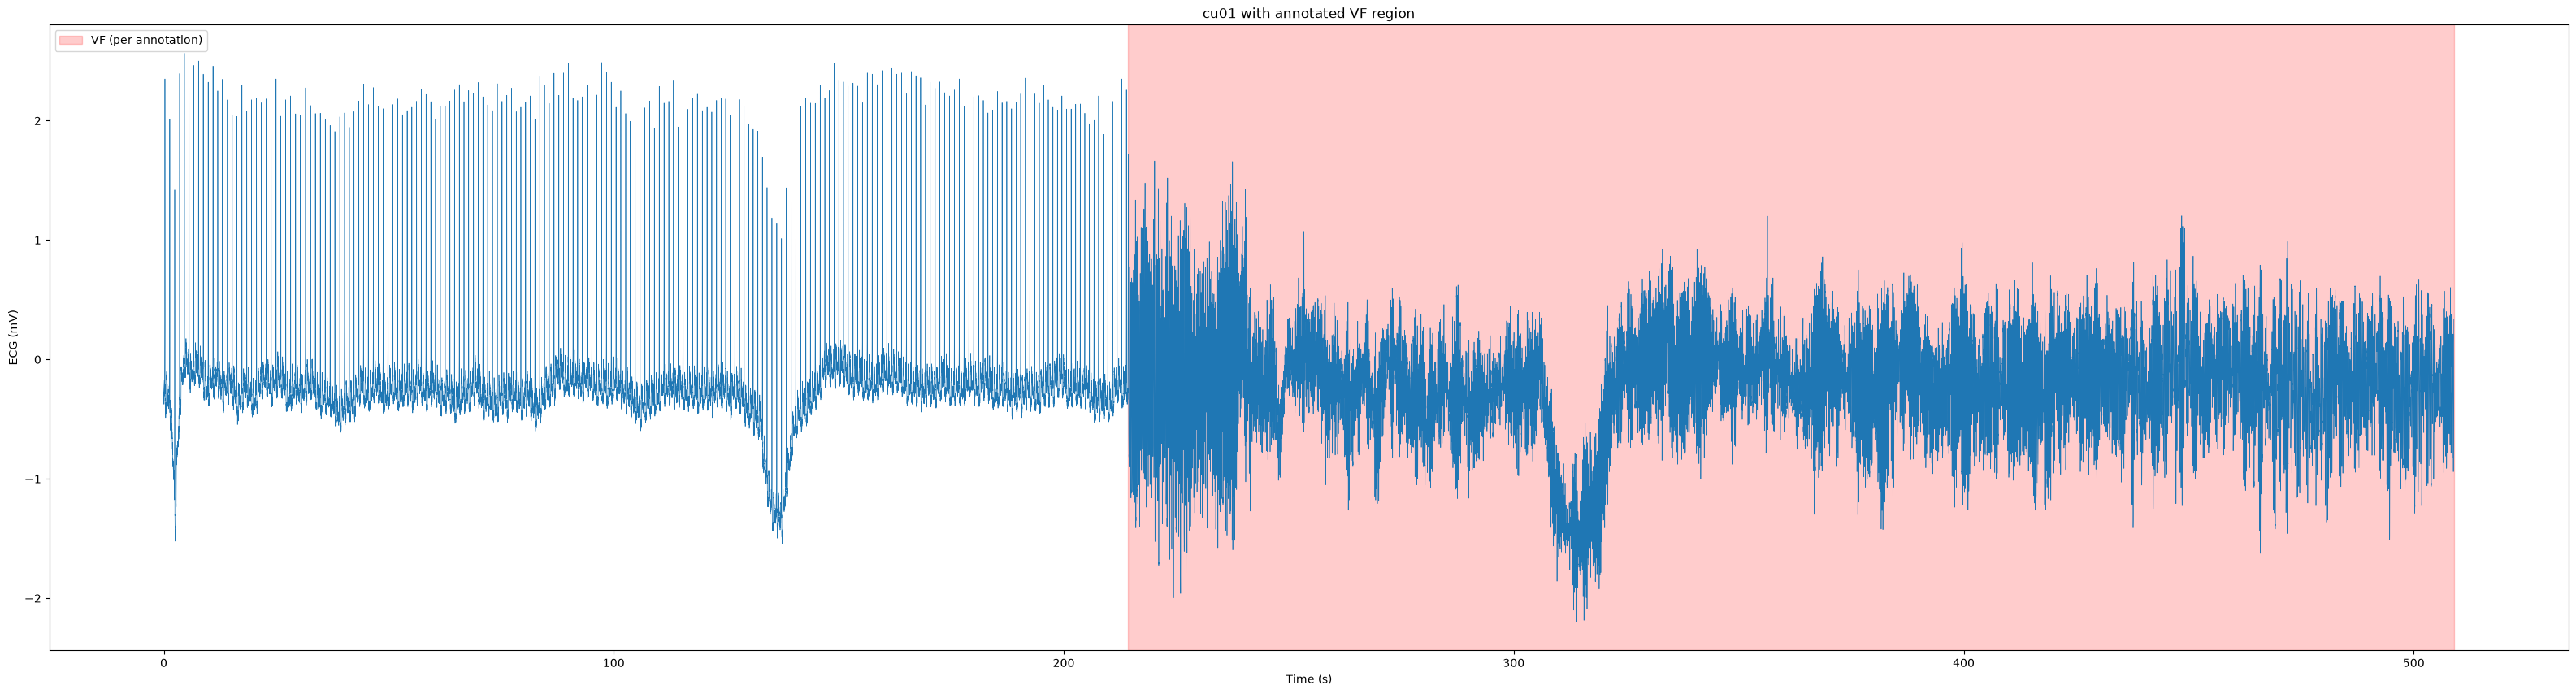

In [72]:
rec_path = os.path.join(cudb_path, 'cu01')
record = wfdb.rdrecord(rec_path)
signal = record.p_signal[:, 0]
entries, record_len = scan_record(rec_path)

vf_start = next(s for s, sym, _ in entries if sym == '[')
vf_end_candidates = [s for s, sym, _ in entries if sym == ']']
vf_end = vf_end_candidates[0] if vf_end_candidates else record_len - 1

time = np.arange(record_len) / fs

plt.figure(figsize=(40, 10))
plt.plot(time, signal, linewidth=0.5)
plt.axvspan(vf_start/fs, vf_end/fs, color='red', alpha=0.2, label='VF (per annotation)')
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title('cu01 with annotated VF region')
plt.legend()
plt.show()

Episodes (start, end) in samples: [(np.int64(38828), np.int64(52738)), (np.int64(55945), np.int64(60883)), (np.int64(63640), np.int64(86487)), (np.int64(92430), np.int64(118792))]


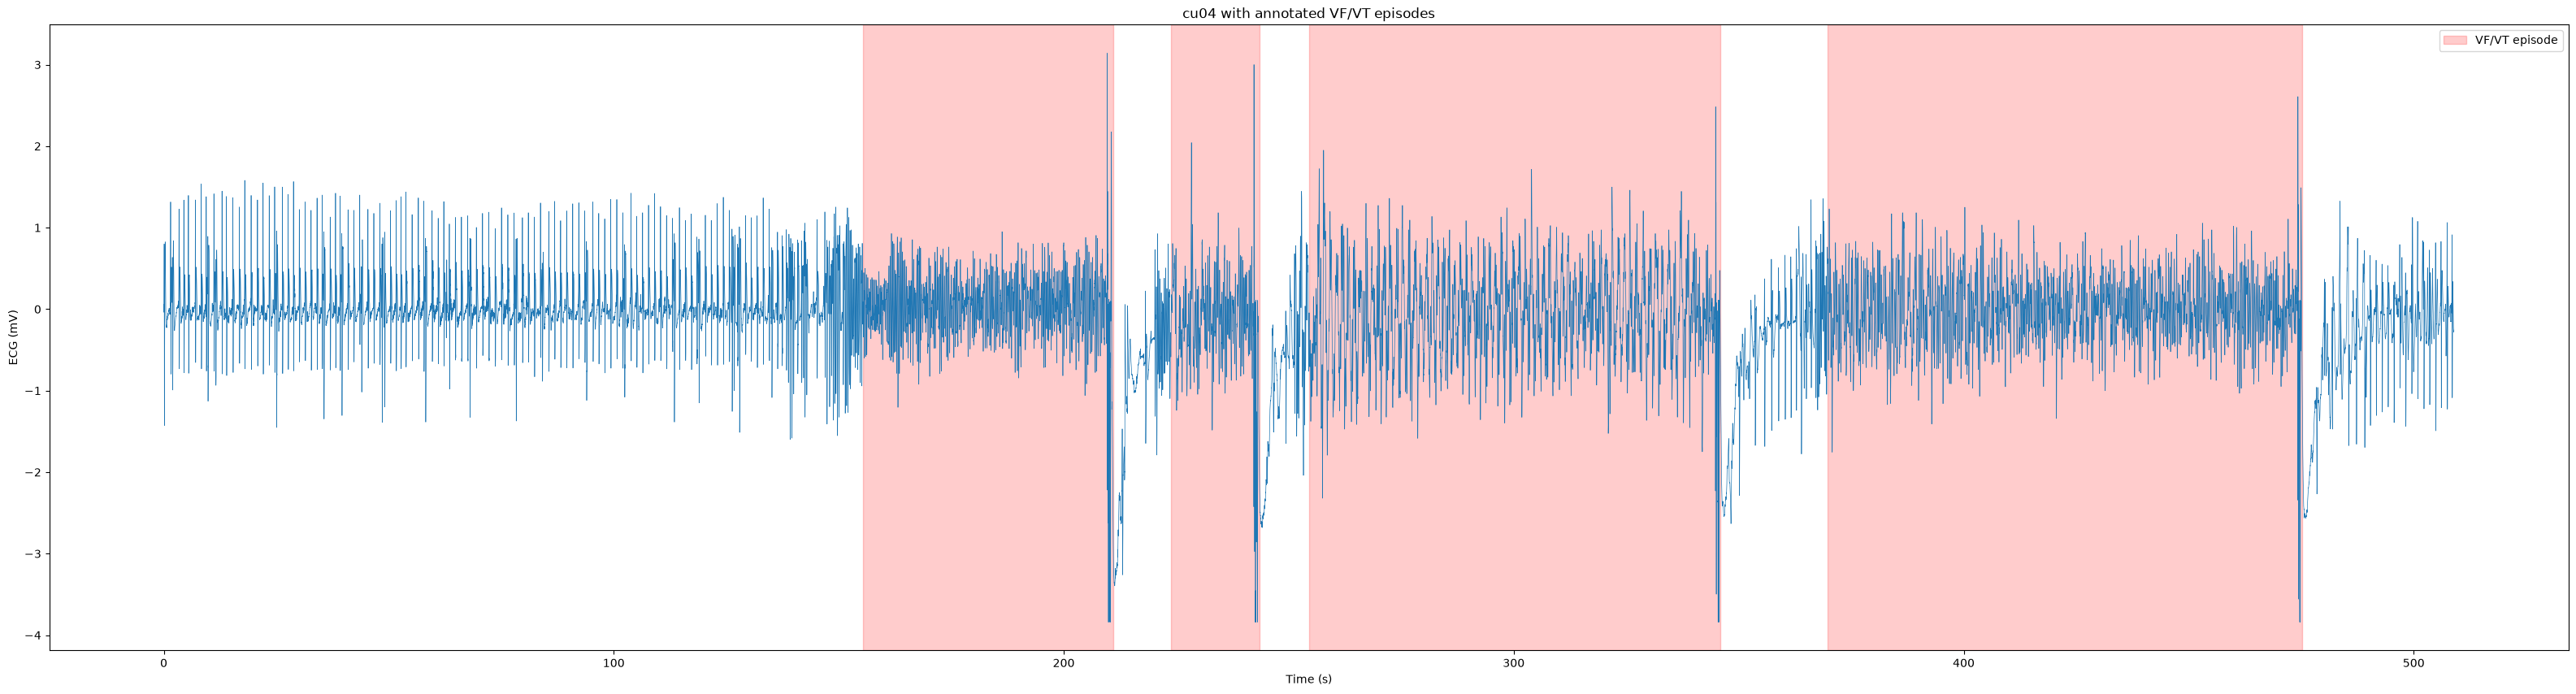

In [73]:
rec_path = os.path.join(cudb_path, 'cu04')
record = wfdb.rdrecord(rec_path)
signal = record.p_signal[:, 0]
entries, record_len = scan_record(rec_path)

rhythm_markers = [(s, sym) for s, sym, _ in entries if sym in ['[', ']']]

episodes = []
open_sample = None
for s, sym in rhythm_markers:
    if sym == '[':
        open_sample = s
    elif sym == ']' and open_sample is not None:
        episodes.append((open_sample, s))
        open_sample = None
if open_sample is not None:
    episodes.append((open_sample, record_len - 1))

print("Episodes (start, end) in samples:", episodes)

time = np.arange(record_len) / fs

plt.figure(figsize=(40, 10))
plt.plot(time, signal, linewidth=0.5)
for i, (start, end) in enumerate(episodes):
    plt.axvspan(start/fs, end/fs, color='red', alpha=0.2, label='VF/VT episode' if i == 0 else None)
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title('cu04 with annotated VF/VT episodes')
plt.legend()
plt.show()

In [ ]:
# calm VF baseline: early part of 1st episode before the shock artifact
vf_baseline_start = 38828 + 250   
vf_baseline = signal[vf_baseline_start : vf_baseline_start + 1250]  # 5 seconds of calm VF

print("Calm VF baseline stats:")
print("  min:", vf_baseline.min(), "max:", vf_baseline.max())
print("  peak-to-peak:", vf_baseline.max() - vf_baseline.min())

# now compare the spike window against THIS baseline instead
spike_ptp = 6.98  # from our last cell
vf_baseline_ptp = vf_baseline.max() - vf_baseline.min()
print("\nSpike peak-to-peak:", spike_ptp)
print("Ratio to calm-VF baseline (not normal-rhythm baseline):", spike_ptp / vf_baseline_ptp)

Calm VF baseline stats:
  min: -0.62 max: 0.5325
  peak-to-peak: 1.1524999999999999

Spike peak-to-peak: 6.98
Ratio to calm-VF baseline (not normal-rhythm baseline): 6.056399132321042


In [77]:
results = []
for i, (start, end) in enumerate(episodes):
    baseline_start = start + 250
    vf_baseline = signal[baseline_start : baseline_start + 1250]
    baseline_ptp = vf_baseline.max() - vf_baseline.min()

    # search window: 3 seconds (750 samples) before/after ']'
    search_start = max(start, end - 750)
    search_end = min(len(signal), end + 750)
    search_region = signal[search_start:search_end]

    local_max = search_region.max()
    local_min = search_region.min()
    local_max_idx = search_start + np.argmax(search_region)
    local_min_idx = search_start + np.argmin(search_region)

    spike_ptp = local_max - local_min
    ratio = spike_ptp / baseline_ptp

    results.append((i+1, local_max_idx, local_min_idx, baseline_ptp, spike_ptp, ratio))
    print(f"Episode {i+1}: local_max at {local_max_idx} (val={local_max:.2f}), "
          f"local_min at {local_min_idx} (val={local_min:.2f}), "
          f"baseline_ptp={baseline_ptp:.3f}, spike_ptp={spike_ptp:.3f}, ratio={ratio:.2f}")

Episode 1: local_max at 52417 (val=3.14), local_min at 52475 (val=-3.84), baseline_ptp=1.152, spike_ptp=6.980, ratio=6.06
Episode 2: local_max at 60569 (val=3.00), local_min at 60633 (val=-3.84), baseline_ptp=3.285, spike_ptp=6.840, ratio=2.08
Episode 3: local_max at 86218 (val=2.48), local_min at 86349 (val=-3.84), baseline_ptp=4.270, spike_ptp=6.322, ratio=1.48
Episode 4: local_max at 118567 (val=2.61), local_min at 118667 (val=-3.84), baseline_ptp=2.570, spike_ptp=6.447, ratio=2.51


In [78]:
print("Global min of cu04 signal:", signal.min())
print("Global max of cu04 signal:", signal.max())
print("Count of samples at exactly the global min:", np.sum(signal == signal.min()))

Global min of cu04 signal: -3.84
Global max of cu04 signal: 3.14
Count of samples at exactly the global min: 68


In [80]:
records_to_check = ['cu01', 'cu03', 'cu06', 'cu08', 'cu10', 'cu16', 'cu21', 'cu30']

for rec in records_to_check:
    rec_path = os.path.join(cudb_path, rec)
    r = wfdb.rdrecord(rec_path)
    sig = r.p_signal[:, 0]
    print(f"{rec}: min={sig.min():.3f}, max={sig.max():.3f}, "
          f"count_at_min={np.sum(sig == sig.min())}, count_at_max={np.sum(sig == sig.max())}")

cu01: min=-2.200, max=2.565, count_at_min=1, count_at_max=1
cu03: min=nan, max=nan, count_at_min=0, count_at_max=0
cu06: min=nan, max=nan, count_at_min=0, count_at_max=0
cu08: min=nan, max=nan, count_at_min=0, count_at_max=0
cu10: min=nan, max=nan, count_at_min=0, count_at_max=0
cu16: min=nan, max=nan, count_at_min=0, count_at_max=0
cu21: min=nan, max=nan, count_at_min=0, count_at_max=0
cu30: min=nan, max=nan, count_at_min=0, count_at_max=0


In [81]:
rec_path = os.path.join(cudb_path, 'cu03')
r = wfdb.rdrecord(rec_path)
sig = r.p_signal[:, 0]

print("Total samples:", len(sig))
print("Number of NaN samples:", np.isnan(sig).sum())
print("First NaN index:", np.argmax(np.isnan(sig)) if np.isnan(sig).any() else "none")

# look at raw values around the first NaN
first_nan = np.argmax(np.isnan(sig))
print("Values around first NaN:", sig[max(0,first_nan-5):first_nan+10])

Total samples: 127232
Number of NaN samples: 4
First NaN index: 119405
Values around first NaN: [-2.42  -2.685 -2.765 -3.54  -4.97     nan    nan    nan    nan -4.7
 -3.625 -3.125 -2.785 -2.295 -1.86 ]


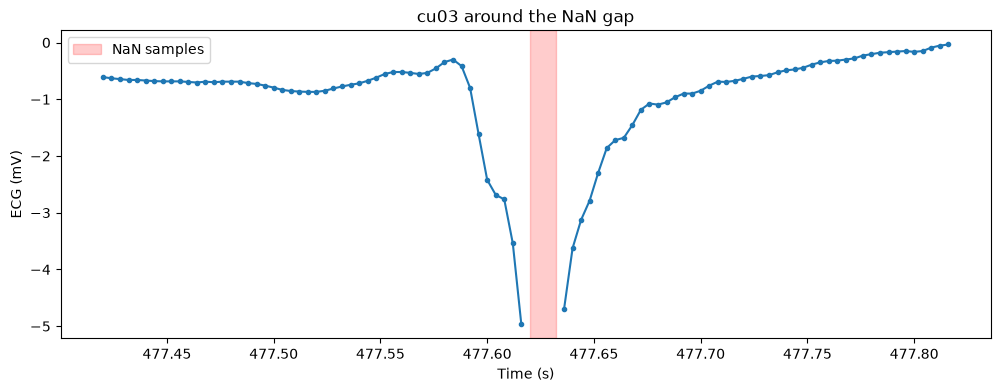

In [82]:
rec_path = os.path.join(cudb_path, 'cu03')
r = wfdb.rdrecord(rec_path)
sig = r.p_signal[:, 0]

first_nan = 119405
window = sig[first_nan - 50 : first_nan + 50]
time = np.arange(first_nan - 50, first_nan + 50) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, window, marker='o', markersize=3)
plt.axvspan((first_nan)/fs, (first_nan+3)/fs, color='red', alpha=0.2, label='NaN samples')
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title('cu03 around the NaN gap')
plt.legend()
plt.show()

Records with NaNs: {'cu02': np.int64(538), 'cu03': np.int64(4), 'cu05': np.int64(52), 'cu06': np.int64(62), 'cu08': np.int64(496), 'cu09': np.int64(1099), 'cu10': np.int64(453), 'cu11': np.int64(1282), 'cu12': np.int64(271), 'cu13': np.int64(338), 'cu14': np.int64(14), 'cu16': np.int64(79), 'cu17': np.int64(683), 'cu19': np.int64(1605), 'cu20': np.int64(1635), 'cu21': np.int64(2146), 'cu22': np.int64(1018), 'cu23': np.int64(2416), 'cu24': np.int64(2320), 'cu25': np.int64(150), 'cu26': np.int64(7368), 'cu27': np.int64(2278), 'cu29': np.int64(888), 'cu30': np.int64(7443), 'cu31': np.int64(200), 'cu32': np.int64(14), 'cu33': np.int64(234), 'cu35': np.int64(576)}


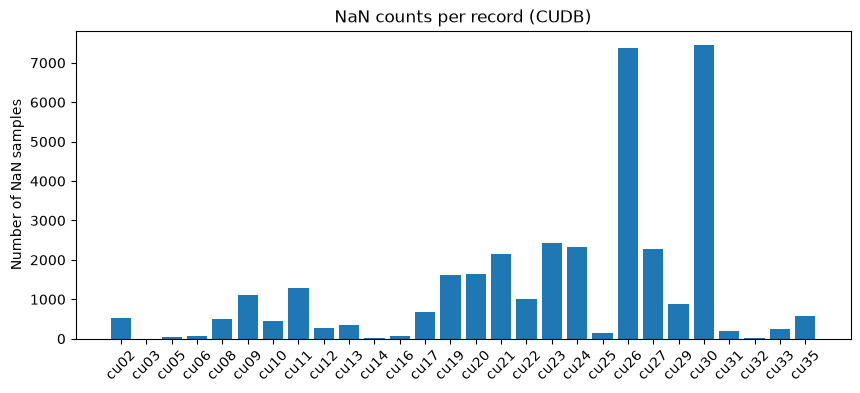

In [83]:
nan_counts = {}
for rec in records:
    r = wfdb.rdrecord(os.path.join(cudb_path, rec))
    sig = r.p_signal[:, 0]
    count = np.isnan(sig).sum()
    if count > 0:
        nan_counts[rec] = count

print("Records with NaNs:", nan_counts)

if nan_counts:
    plt.figure(figsize=(10, 4))
    plt.bar(nan_counts.keys(), nan_counts.values())
    plt.ylabel('Number of NaN samples')
    plt.title('NaN counts per record (CUDB)')
    plt.xticks(rotation=45)
    plt.show()

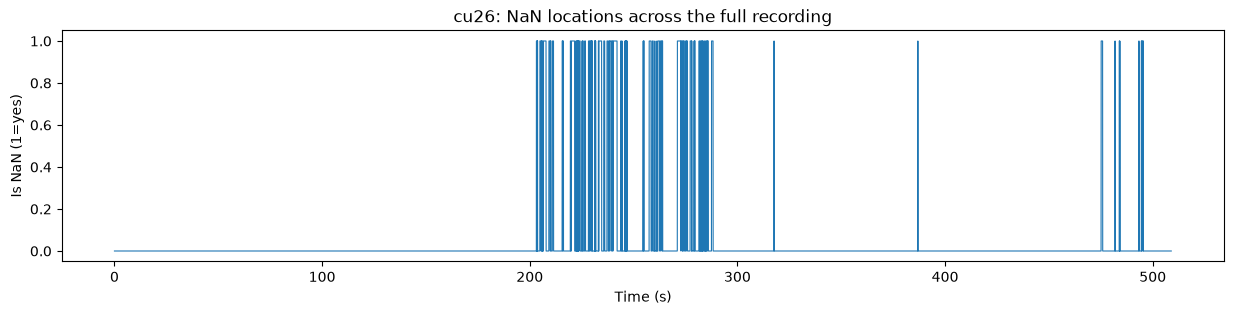

cu26: 98 separate NaN block(s)
  block from sample 50799 to 50810 (duration 0.04s)
  block from sample 50859 to 50899 (duration 0.16s)
  block from sample 50906 to 50914 (duration 0.03s)
  block from sample 50928 to 50934 (duration 0.02s)
  block from sample 51209 to 51357 (duration 0.59s)
  block from sample 51380 to 51441 (duration 0.24s)
  block from sample 51478 to 51479 (duration 0.00s)
  block from sample 51552 to 51566 (duration 0.06s)
  block from sample 51567 to 51569 (duration 0.01s)
  block from sample 51638 to 51957 (duration 1.28s)
  block from sample 52295 to 52460 (duration 0.66s)
  block from sample 52475 to 52547 (duration 0.29s)
  block from sample 52717 to 52857 (duration 0.56s)
  block from sample 53892 to 53895 (duration 0.01s)
  block from sample 53901 to 53945 (duration 0.18s)
  block from sample 53959 to 54048 (duration 0.36s)
  block from sample 54879 to 54918 (duration 0.16s)
  block from sample 54997 to 55395 (duration 1.59s)
  block from sample 55565 to 5557

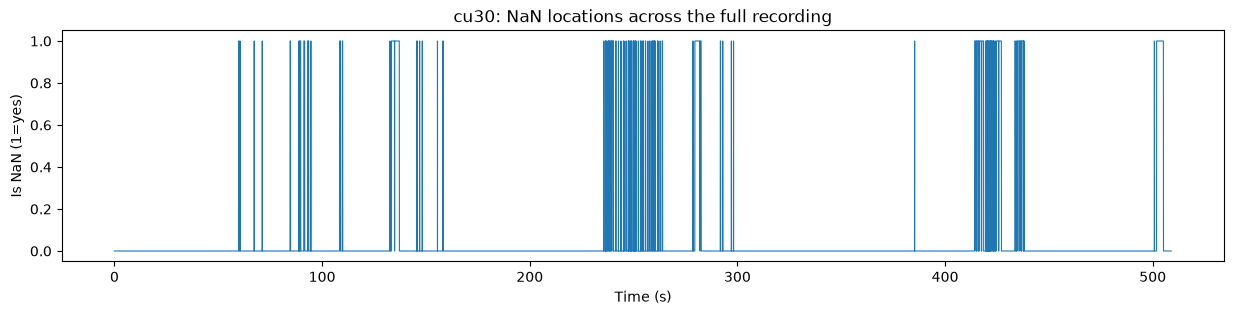

cu30: 123 separate NaN block(s)
  block from sample 14938 to 14992 (duration 0.22s)
  block from sample 15095 to 15121 (duration 0.10s)
  block from sample 16809 to 16833 (duration 0.10s)
  block from sample 17780 to 17798 (duration 0.07s)
  block from sample 21133 to 21197 (duration 0.26s)
  block from sample 22177 to 22196 (duration 0.08s)
  block from sample 22286 to 22290 (duration 0.02s)
  block from sample 22334 to 22419 (duration 0.34s)
  block from sample 22789 to 22901 (duration 0.45s)
  block from sample 22907 to 22910 (duration 0.01s)
  block from sample 23251 to 23287 (duration 0.14s)
  block from sample 23291 to 23294 (duration 0.01s)
  block from sample 23305 to 23378 (duration 0.29s)
  block from sample 23638 to 23645 (duration 0.03s)
  block from sample 27095 to 27206 (duration 0.44s)
  block from sample 27425 to 27475 (duration 0.20s)
  block from sample 33153 to 33167 (duration 0.06s)
  block from sample 33341 to 33707 (duration 1.46s)
  block from sample 33729 to 342

In [84]:
for rec in ['cu26', 'cu30']:
    r = wfdb.rdrecord(os.path.join(cudb_path, rec))
    sig = r.p_signal[:, 0]
    nan_mask = np.isnan(sig)
    time = np.arange(len(sig)) / fs

    plt.figure(figsize=(15, 3))
    plt.plot(time, nan_mask.astype(int), linewidth=0.8)
    plt.xlabel('Time (s)')
    plt.ylabel('Is NaN (1=yes)')
    plt.title(f'{rec}: NaN locations across the full recording')
    plt.show()

    # also print the boundaries of each contiguous NaN block
    diffs = np.diff(nan_mask.astype(int))
    starts = np.where(diffs == 1)[0] + 1
    ends = np.where(diffs == -1)[0] + 1
    if nan_mask[0]:
        starts = np.insert(starts, 0, 0)
    if nan_mask[-1]:
        ends = np.append(ends, len(sig))
    print(f"{rec}: {len(starts)} separate NaN block(s)")
    for s, e in zip(starts, ends):
        print(f"  block from sample {s} to {e} (duration {(e-s)/fs:.2f}s)")
    print()

In [85]:
for rec in ['cu26', 'cu30']:
    entries, record_len = scan_record(os.path.join(cudb_path, rec))
    rhythm_markers = [(s, sym, note) for s, sym, note in entries if sym in ['[', ']', '+']]
    print(rec, 'rhythm markers:', rhythm_markers)

cu26 rhythm markers: [(np.int64(36382), '[', ''), (np.int64(50813), ']', ''), (np.int64(119316), '[', ''), (np.int64(123315), ']', '')]
cu30 rhythm markers: [(np.int64(6859), '[', ''), (np.int64(33147), ']', ''), (np.int64(42317), '[', ''), (np.int64(69626), ']', ''), (np.int64(87322), '[', '')]


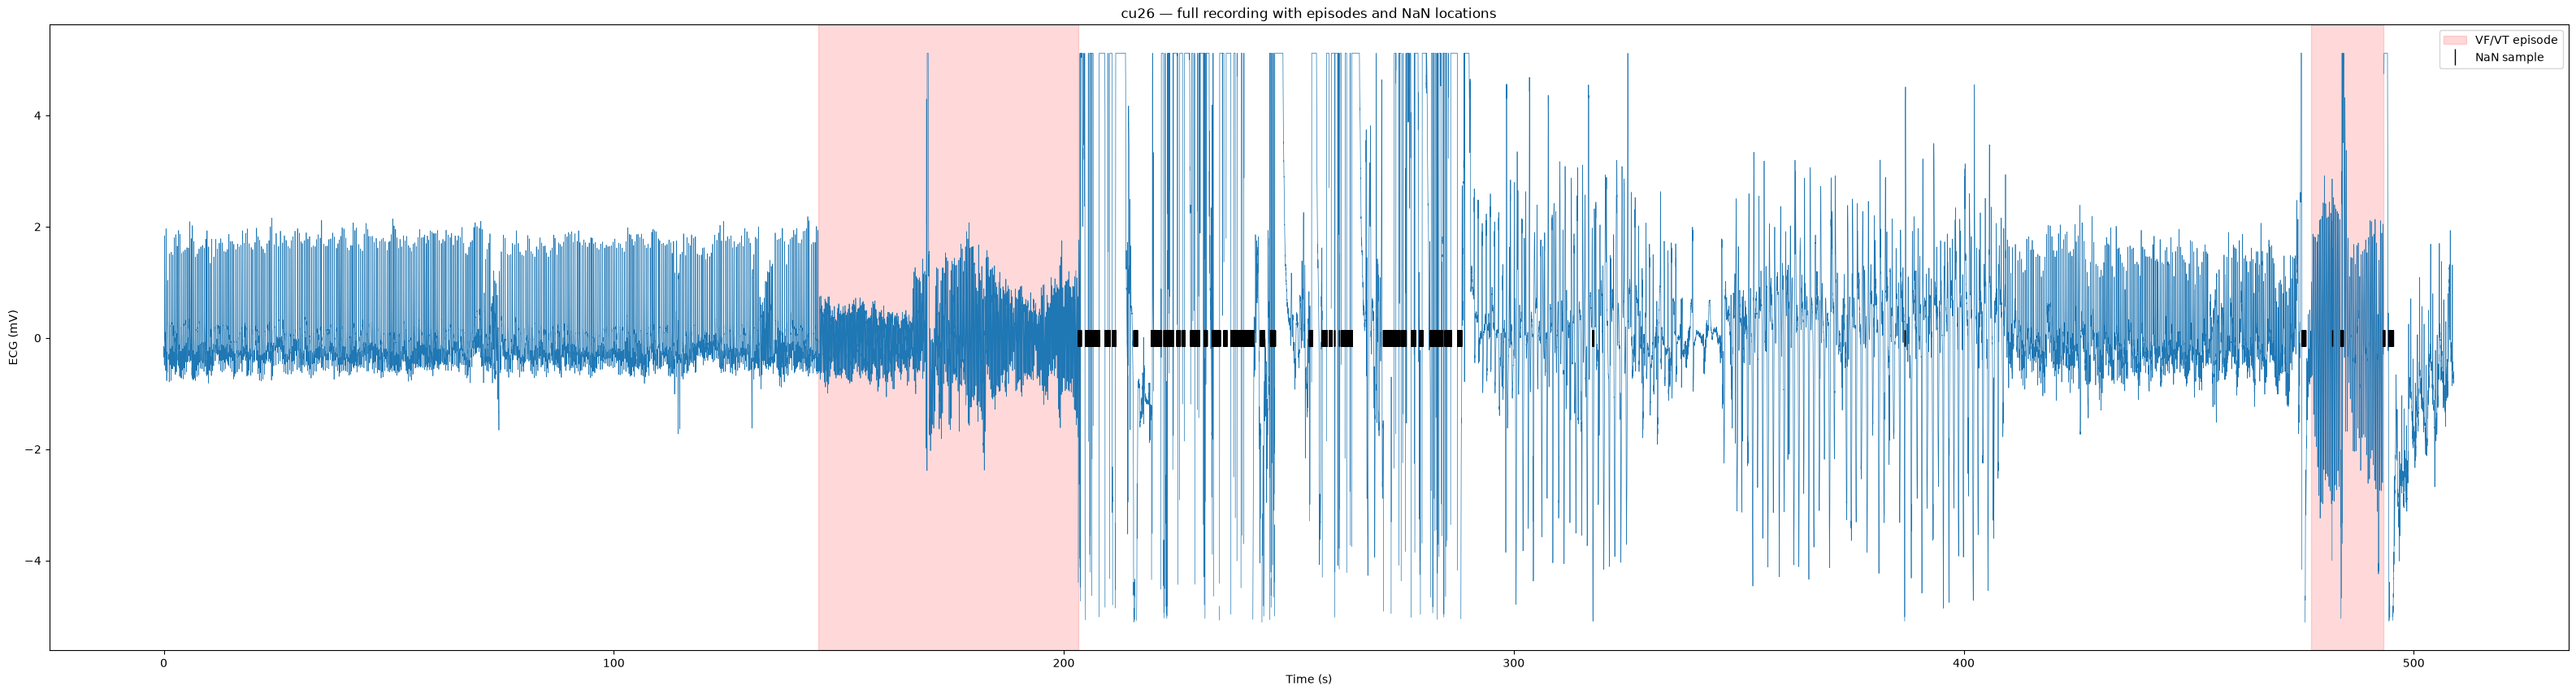

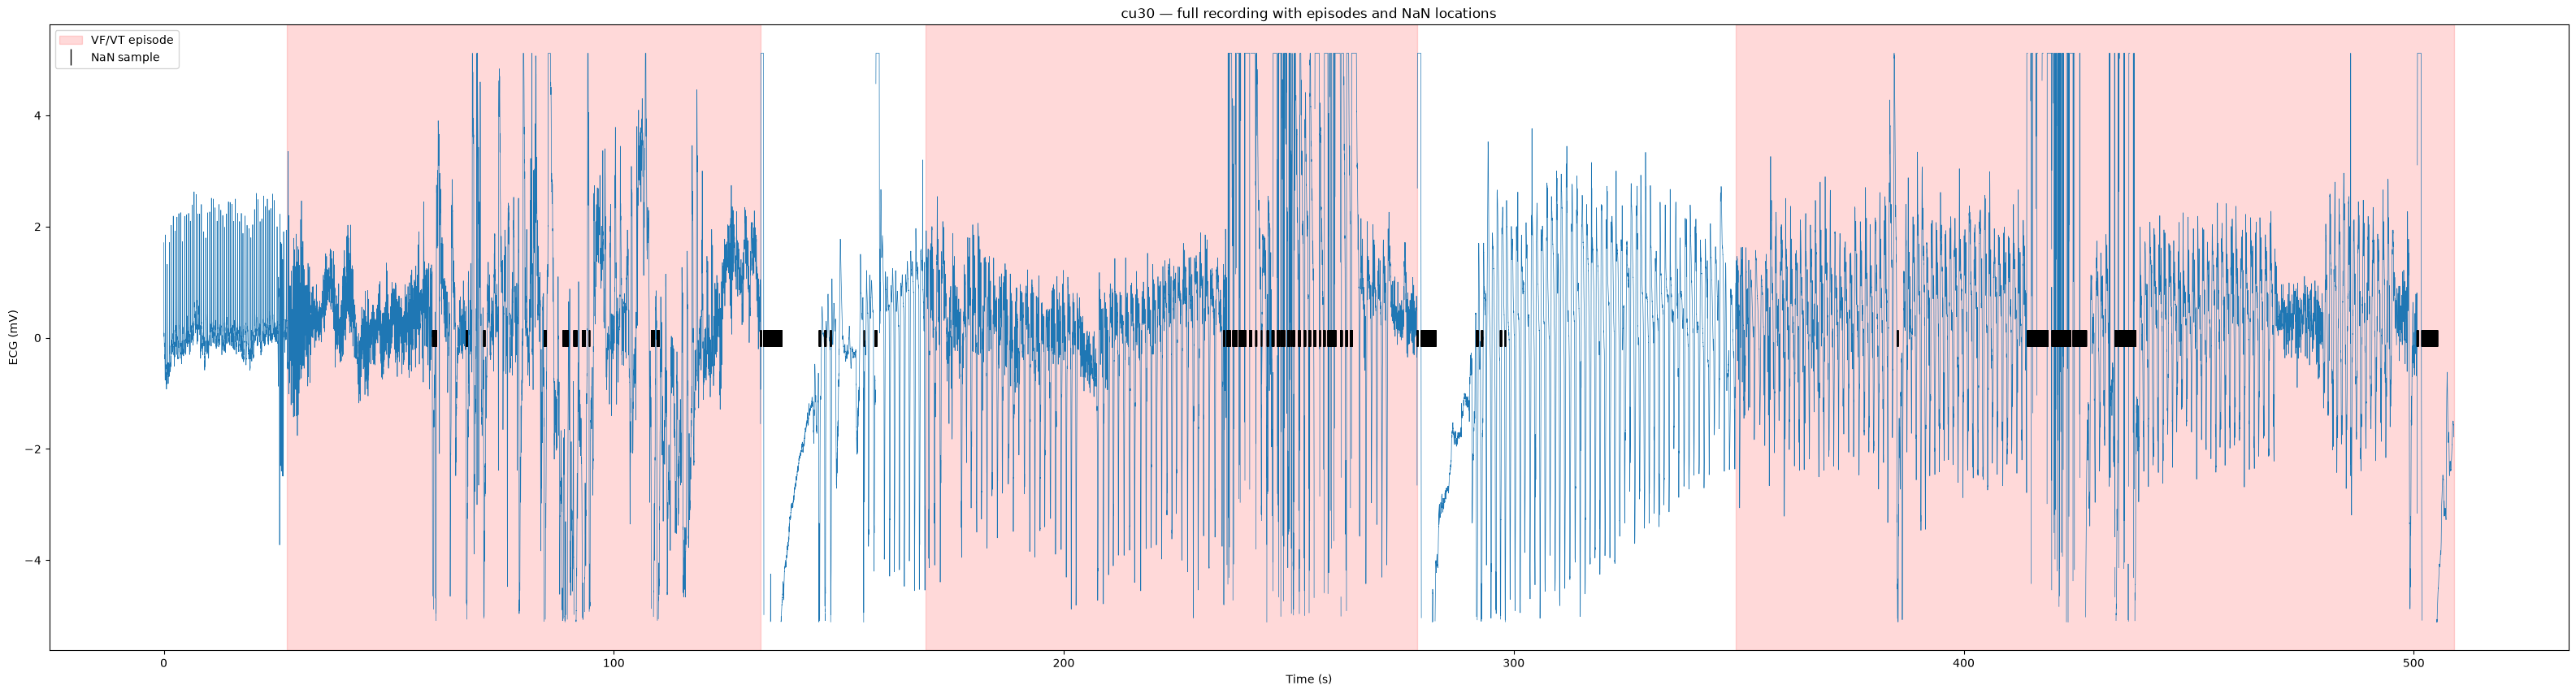

In [86]:
for rec in ['cu26', 'cu30']:
    rec_path = os.path.join(cudb_path, rec)
    record = wfdb.rdrecord(rec_path)
    signal = record.p_signal[:, 0]
    entries, record_len = scan_record(rec_path)

    rhythm_markers = [(s, sym) for s, sym, _ in entries if sym in ['[', ']']]
    episodes = []
    open_sample = None
    for s, sym in rhythm_markers:
        if sym == '[':
            open_sample = s
        elif sym == ']' and open_sample is not None:
            episodes.append((open_sample, s))
            open_sample = None
    if open_sample is not None:
        episodes.append((open_sample, record_len - 1))

    nan_mask = np.isnan(signal)
    time = np.arange(record_len) / fs

    plt.figure(figsize=(40, 10))
    plt.plot(time, signal, linewidth=0.5)
    for i, (start, end) in enumerate(episodes):
        plt.axvspan(start/fs, end/fs, color='red', alpha=0.15, label='VF/VT episode' if i == 0 else None)
    plt.plot(time[nan_mask], np.zeros(nan_mask.sum()), '|', color='black', markersize=15, label='NaN sample')
    plt.xlabel('Time (s)')
    plt.ylabel('ECG (mV)')
    plt.title(f'{rec} — full recording with episodes and NaN locations')
    plt.legend()
    plt.show()

In [88]:
for rec in ['cu26', 'cu30']:
    rec_path = os.path.join(cudb_path, rec)
    record = wfdb.rdrecord(rec_path)
    signal = record.p_signal[:, 0]
    nan_mask = np.isnan(signal)

    diffs = np.diff(nan_mask.astype(int))
    starts = np.where(diffs == 1)[0] + 1
    if nan_mask[0]:
        starts = np.insert(starts, 0, 0)

    print(f"--- {rec}: amplitude right before each NaN block ---")
    for s in starts:
        pre_window = signal[max(0, s-125):s]  # 0.5s right before the gap
        pre_window = pre_window[~np.isnan(pre_window)]
        if len(pre_window) > 0:
            print(f"  gap at sample {s}: pre-gap max_abs={np.max(np.abs(pre_window)):.2f}")

--- cu26: amplitude right before each NaN block ---
  gap at sample 50799: pre-gap max_abs=1.78
  gap at sample 50859: pre-gap max_abs=4.39
  gap at sample 50906: pre-gap max_abs=5.12
  gap at sample 50928: pre-gap max_abs=5.12
  gap at sample 51209: pre-gap max_abs=5.12
  gap at sample 51380: pre-gap max_abs=5.12
  gap at sample 51478: pre-gap max_abs=5.12
  gap at sample 51552: pre-gap max_abs=5.12
  gap at sample 51567: pre-gap max_abs=5.12
  gap at sample 51638: pre-gap max_abs=5.12
  gap at sample 52295: pre-gap max_abs=5.12
  gap at sample 52475: pre-gap max_abs=5.12
  gap at sample 52717: pre-gap max_abs=5.12
  gap at sample 53892: pre-gap max_abs=5.02
  gap at sample 53901: pre-gap max_abs=5.11
  gap at sample 53959: pre-gap max_abs=5.11
  gap at sample 54879: pre-gap max_abs=4.34
  gap at sample 54997: pre-gap max_abs=5.12
  gap at sample 55565: pre-gap max_abs=5.12
  gap at sample 55586: pre-gap max_abs=5.12
  gap at sample 55680: pre-gap max_abs=5.12
  gap at sample 55725: p

In [89]:
ann = wfdb.rdann(os.path.join(cudb_path, 'cu26'), 'atr')
for s, sym, note in zip(ann.sample, ann.symbol, ann.aux_note):
    clean_note = note.strip('\x00')
    if sym != 'N':
        print(s, repr(sym), repr(clean_note))

36382 '[' ''
50813 ']' ''
50830 '~' ''
53645 '~' ''
53788 '~' ''
54049 '~' ''
54875 '~' ''
72543 '~' ''
118681 '~' ''
118973 '~' ''
119316 '[' ''
123315 ']' ''
123330 '~' ''
123866 '~' ''
